<a href="https://www.kaggle.com/code/danielmahulae/proyek-sentiment-analysis-online-travel-agent-ota?scriptVersionId=305475817" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Sentimen Analisis Review APK Play Store**



# **Import Library**

In [1]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import logging
from concurrent.futures import ThreadPoolExecutor
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.4 MB/s eta 0:00:00a 0:00:01


In [2]:
import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab')
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stop words) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Loading Dataset

Pada proyek ini, saya akan melakukan analisis sentimen terhadap ulasan dan pendapat pengguna terkait 3 aplikasi dan membandingkan dominasi komentar pada ketiga aplikasi tersebut. aplikasi tersebut adalah "Traveloka, Tiket.com, dan Agoda." di Play Store. Analisis sentimen akan membantu kita mengidentifikasi apakah ulasan pengguna terhadap ketiga aplikasi tersebut cenderung positif, negatif, atau netral.

In [3]:
# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.read_csv('/kaggle/input/datasets/danielmahulae/data-ulasan/ulasan_travel_apps.csv', encoding="utf-8")
app_reviews_df.shape

(139911, 12)

In [4]:
print(app_reviews_df['appName'].value_counts())

appName
Traveloka    50000
Tiket.com    50000
Agoda        39911
Name: count, dtype: int64


Terlihat bahwa seluruh review pada aplikasi agoda hanya memiliki 39911 review

In [5]:
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,appName
0,a8745141-90b9-4560-b017-3a52c2932816,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Awlanya sih Tertarik ya pas udah ada TPayleter...,1,0,5.39.0,2026-02-28 05:53:33,"Hai Hafidz, kami mohon maaf atas ketidaknyaman...",2026-02-28 06:22:41,5.39.0,Traveloka
1,717ea19a-d102-46f3-8b40-4d466aba7147,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Saya pengguna traveloka sudah lama, pesan hote...",3,54,5.38.0,2026-02-28 03:18:08,"Halo Asep Buddy Mulyono, terima kasih telah me...",2021-04-30 14:32:58,5.38.0,Traveloka
2,c9e5559c-b79d-498d-aaf3-4f1deffe95d7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Awalnya sangat baik dan sangat membantu TPayla...,3,5,5.38.0,2026-02-26 11:08:26,"Hai Glend, kami mohon maaf terkait masalah yan...",2026-02-26 12:17:34,5.38.0,Traveloka
3,bf46cc05-9bc7-4ac4-8594-8c460749bc47,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sering pindah tanggal sendiri, padahal sudah d...",1,10,5.38.0,2026-02-22 11:05:47,"Hai Dicky, mohon maaf atas kendala yang Anda t...",2026-02-17 02:10:39,5.38.0,Traveloka
4,19284ab0-5f6c-4502-be4a-90fcab5aa5f2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Hati2 aplikasi ini banyak jebakan asuransi ket...,1,4,5.38.0,2026-02-23 08:20:36,"Hai Rizal, mohon maaf atas kendala yang Anda a...",2026-02-23 09:12:23,5.38.0,Traveloka


In [6]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139911 entries, 0 to 139910
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              139911 non-null  object
 1   userName              139911 non-null  object
 2   userImage             139911 non-null  object
 3   content               139903 non-null  object
 4   score                 139911 non-null  int64 
 5   thumbsUpCount         139911 non-null  int64 
 6   reviewCreatedVersion  117176 non-null  object
 7   at                    139911 non-null  object
 8   replyContent          59091 non-null   object
 9   repliedAt             59096 non-null   object
 10  appVersion            117176 non-null  object
 11  appName               139911 non-null  object
dtypes: int64(2), object(10)
memory usage: 12.8+ MB


In [7]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = app_reviews_df.drop_duplicates()

In [8]:
clean_df = clean_df.dropna(subset=['content'])

In [9]:
# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
clean_df.shape

(139903, 12)

#  Preprocessing

In [10]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]', '', text) # remove RT
    text = re.sub(r"http\S+", '', text) # remove link
    

    text = text.replace('/', ' ')
    text = text.replace('\n', ' ') # replace new line into space
    text = text.replace('.', ' ')
    
    text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation))) # remove all punctuations(tanda baca)
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove numbers
    text = text.strip(' ') # remove characters space from both left and right text
    text = re.sub(r'\s+', ' ', text).strip() # remove spasi ganda
    return text


def casefoldingText(text): # Converting all the characters in a text into lower case
    text = text.lower()
    return text

def tokenizingText(text): # Tokenizing or splitting a string, text into a list of tokens
    text = word_tokenize(text)
    return text

def filteringText(text): # Remove stopwords in a text
    listStopwords = set(stopwords.words('indonesian')) # buat ke set daftar stopword indo
    listStopwords1 = set(stopwords.words('english'))   # ambil juga dari inggris
    listStopwords.update(listStopwords1)                # Gabungkan
    listStopwords.update(['dr','deh','iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"]) # stopword manual
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text     # Kembalikan teks yang sudah dibersihkan.

def stemmingText(text): # Reducing a word to its word stem that affixes to suffixes and prefixes or to the roots of words
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

    return stemmed_text
def toSentence(list_words): # Convert list of words into sentence
    sentence = ' '.join(word for word in list_words)
    return sentence

## Daftar kata-kata slang

In [11]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "gk": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin",
             "apk": "aplikasi",
    "app": "aplikasi", "cs":"customer service",
    "udh": "sudah",
    "sdh": "sudah",
    "pesen": "pesan",
    "skrg": "sekarang",
    "ngerugiin": "merugikan",
    "bugnya": "bug",
    "tarohan": "taruhan",
    "prose": "proses",
    "trus": "terus",
    "rb": "ribu",
    "rek": "rekening",
    "gajelas": "tidak jelas",
    "burukkkkk": "buruk",
    "dr": "dari",
    "g": "tidak",
    "ok": "oke",
    "anjeng": "anjing", 
  "nunggu":"menunggu"}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

Kamus slang atau daftar kata-kata slang ini adalah kumpulan kata-kata slang bahasa Indonesia beserta terjemahan atau artinya dalam bahasa formal.

In [12]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [13]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,appName,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,a8745141-90b9-4560-b017-3a52c2932816,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Awlanya sih Tertarik ya pas udah ada TPayleter...,1,0,5.39.0,2026-02-28 05:53:33,"Hai Hafidz, kami mohon maaf atas ketidaknyaman...",2026-02-28 06:22:41,5.39.0,Traveloka,Awlanya sih Tertarik ya pas udah ada TPayleter...,awlanya sih tertarik ya pas udah ada tpayleter...,awlanya sih tertarik iya pas sudah ada tpaylet...,"[awlanya, sih, tertarik, iya, pas, sudah, ada,...","[awlanya, tertarik, pas, tpayleter, setelahnya...",awlanya tertarik pas tpayleter setelahnya bebe...
1,717ea19a-d102-46f3-8b40-4d466aba7147,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Saya pengguna traveloka sudah lama, pesan hote...",3,54,5.38.0,2026-02-28 03:18:08,"Halo Asep Buddy Mulyono, terima kasih telah me...",2021-04-30 14:32:58,5.38.0,Traveloka,Saya pengguna traveloka sudah lama pesan hotel...,saya pengguna traveloka sudah lama pesan hotel...,saya pengguna traveloka sudah lama pesan hotel...,"[saya, pengguna, traveloka, sudah, lama, pesan...","[pengguna, traveloka, pesan, hotel, travel, ke...",pengguna traveloka pesan hotel travel kereta b...
2,c9e5559c-b79d-498d-aaf3-4f1deffe95d7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Awalnya sangat baik dan sangat membantu TPayla...,3,5,5.38.0,2026-02-26 11:08:26,"Hai Glend, kami mohon maaf terkait masalah yan...",2026-02-26 12:17:34,5.38.0,Traveloka,Awalnya sangat baik dan sangat membantu TPayla...,awalnya sangat baik dan sangat membantu tpayla...,awalnya sangat baik dan sangat membantu tpayla...,"[awalnya, sangat, baik, dan, sangat, membantu,...","[membantu, tpaylaternya, level, terima, pas, l...",membantu tpaylaternya level terima pas level l...
3,bf46cc05-9bc7-4ac4-8594-8c460749bc47,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sering pindah tanggal sendiri, padahal sudah d...",1,10,5.38.0,2026-02-22 11:05:47,"Hai Dicky, mohon maaf atas kendala yang Anda t...",2026-02-17 02:10:39,5.38.0,Traveloka,sering pindah tanggal sendiri padahal sudah di...,sering pindah tanggal sendiri padahal sudah di...,sering pindah tanggal sendiri padahal sudah di...,"[sering, pindah, tanggal, sendiri, padahal, su...","[pindah, tanggal, cek, berulang, kali, tanggal...",pindah tanggal cek berulang kali tanggal berpi...
4,19284ab0-5f6c-4502-be4a-90fcab5aa5f2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Hati2 aplikasi ini banyak jebakan asuransi ket...,1,4,5.38.0,2026-02-23 08:20:36,"Hai Rizal, mohon maaf atas kendala yang Anda a...",2026-02-23 09:12:23,5.38.0,Traveloka,Hati aplikasi ini banyak jebakan asuransi keti...,hati aplikasi ini banyak jebakan asuransi keti...,hati aplikasi ini banyak jebakan asuransi keti...,"[hati, aplikasi, ini, banyak, jebakan, asurans...","[hati, aplikasi, jebakan, asuransi, membeli, t...",hati aplikasi jebakan asuransi membeli tiket p...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139906,9b40b296-99f7-4902-8b4e-ca5c4dc88011,Sonny Cakrasana,https://play-lh.googleusercontent.com/a-/ALV-U...,🤡,1,0,NaN,2024-06-28 22:16:47,NaN,NaN,NaN,Agoda,,,,[],[],
139907,a1854c17-2778-4b02-9a0c-283d3af778ac,dayat namasaya,https://play-lh.googleusercontent.com/a-/ALV-U...,😒😒😒😒,1,0,NaN,2025-12-20 11:59:27,NaN,NaN,NaN,Agoda,,,,[],[],
139908,872555de-f010-41f6-8d03-a9818cb05552,Ina Nandi,https://play-lh.googleusercontent.com/a-/ALV-U...,👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎,1,0,NaN,2022-12-17 15:30:08,NaN,NaN,NaN,Agoda,,,,[],[],
139909,1fe4ba77-5766-41b4-88a9-5d163f4a2e82,Sheva Ramadhan,https://play-lh.googleusercontent.com/a-/ALV-U...,👎👎👎,1,0,NaN,2022-05-16 11:19:05,NaN,NaN,NaN,Agoda,,,,[],[],


# Pelabelan

In [14]:
import csv
import requests
from io import StringIO

# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [15]:
# Function to determine sentiment polarity of tweets
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score >0 ):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif

    else:
        polarity = 'neutral'
    # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [16]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))       # pisahkan kolom(unzip atau transpose)
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    65356
negative    44214
neutral     30333
Name: count, dtype: int64


In [17]:
# Sentimen per aplikasi berdasarkan kategori travel
polarity_per_game = pd.crosstab(clean_df['appName'], clean_df['polarity'])
polarity_game = (polarity_per_game.div(polarity_per_game.sum(axis=1), axis=0))*100
print(polarity_game.round(2))

polarity   negative  neutral  positive
appName                               
Agoda         33.50    19.71     46.79
Tiket.com     23.64    28.93     47.43
Traveloka     38.06    16.01     45.94


terlihat bahwa ketiga aplikasi tersebut kebanyakan menerima sentimen positif dibandingkan 2 sentimen lainnya.

In [18]:
# Sentimen per aplikasi berdasarkan jenis sentimen
polarity_game_2 = (polarity_per_game.div(polarity_per_game.sum(axis=0), axis=1))*100
print(polarity_game_2.round(2))

polarity   negative  neutral  positive
appName                               
Agoda         30.23    25.93     28.57
Tiket.com     26.73    47.68     36.29
Traveloka     43.04    26.39     35.14


terlihat bahwa aplikasi traveloka menerima banyak sentimen negatif dibanding 2 aplikasi lainnya, diikuti aplikasi tiket.com yang menerima sentimen netral dan positif terbanyak dibanding 2 aplikasi lainnya.

# Visualisasi

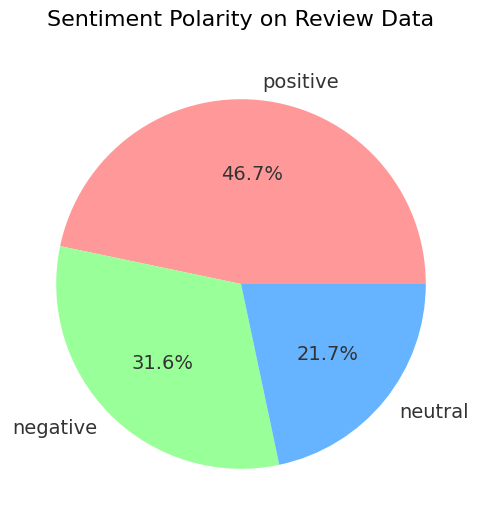

In [19]:
import matplotlib.pyplot as plt

# Membuat objek gambar dan sumbu dengan ukuran (6, 6) inci.
fig, ax = plt.subplots(figsize=(6, 6))

# Mengambil jumlah data polaritas sentimen dari DataFrame 'clean_df' dan menyimpannya dalam list 'sizes'.
sizes = [count for count in clean_df['polarity'].value_counts()]

# Mengambil label atau kategori sentimen dari DataFrame 'clean_df' dan menyimpannya dalam list 'labels'.
labels = list(clean_df['polarity'].value_counts().index)

colors = ['#ff9999', '#99ff99', '#66b3ff', '#ffcc99', '#bcbd22']

# Autopct digunakan untuk menampilkan persentase di dalam setiap potongan pie.
# Textprops digunakan untuk mengatur ukuran font teks dalam pie chart.
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', colors=colors[:len(labels)],textprops={'fontsize': 14,'color': '#333333'})

# Menetapkan judul untuk pie chart dengan ukuran font dan jarak (padding) tertentu.
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

# Menampilkan pie chart.
plt.show()

In [20]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'neutral_tweets' yang hanya berisi tweet dengan polaritas netral.
neutral_tweets = clean_df[clean_df['polarity'] == 'neutral']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'neutral_tweets'.
neutral_tweets = neutral_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'neutral_tweets' berdasarkan 'polarity_score' secara menurun.
neutral_tweets = neutral_tweets.sort_values(by='polarity_score', ascending=False)

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
neutral_tweets = neutral_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
neutral_tweets.index += 1

In [21]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'positive_tweets' yang hanya berisi tweet dengan polaritas positif.
positive_tweets = clean_df[clean_df['polarity'] == 'positive']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'positive_tweets'.
positive_tweets = positive_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'positive_tweets' berdasarkan 'polarity_score' secara menurun.
positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False)

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
positive_tweets = positive_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
positive_tweets.index += 1

In [22]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'negative_tweets' yang hanya berisi tweet dengan polaritas negatif.
negative_tweets = clean_df[clean_df['polarity'] == 'negative']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negative_tweets'.
negative_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'negative_tweets' berdasarkan 'polarity_score' secara menaik (ascending).
negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
negative_tweets = negative_tweets[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
negative_tweets = negative_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
negative_tweets.index += 1

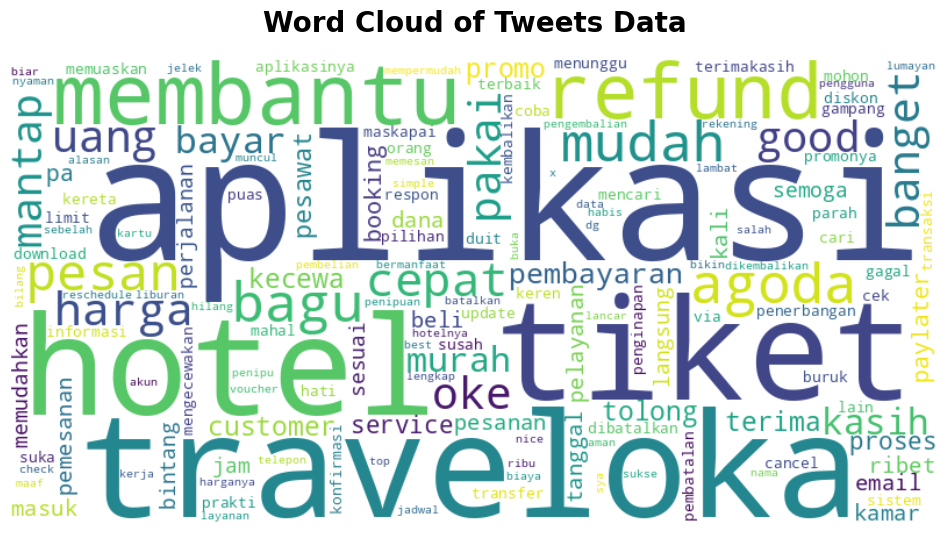

In [23]:
text_data = ' '.join(clean_df['text_stopword'].apply(lambda x: ' '.join(x)))

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',   
    max_words=150,         # Batasi agar tidak terlalu penuh
    min_font_size=10,
    collocations=False     # Menghindari kata yang sama muncul dua kali (duplikat)
).generate(text_data)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Tweets Data', fontsize=20, pad=20, fontweight='bold')
plt.show()

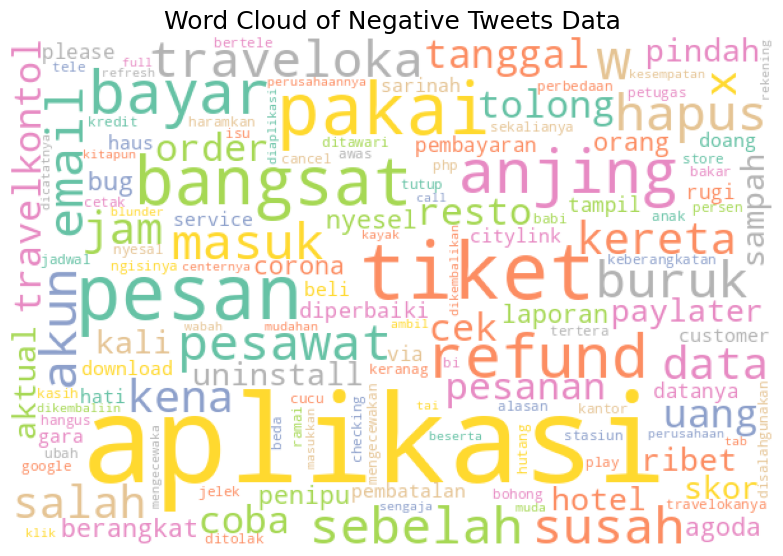

In [24]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet negatif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'negative_tweets'.
for tweet in negative_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', colormap='Set2',min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

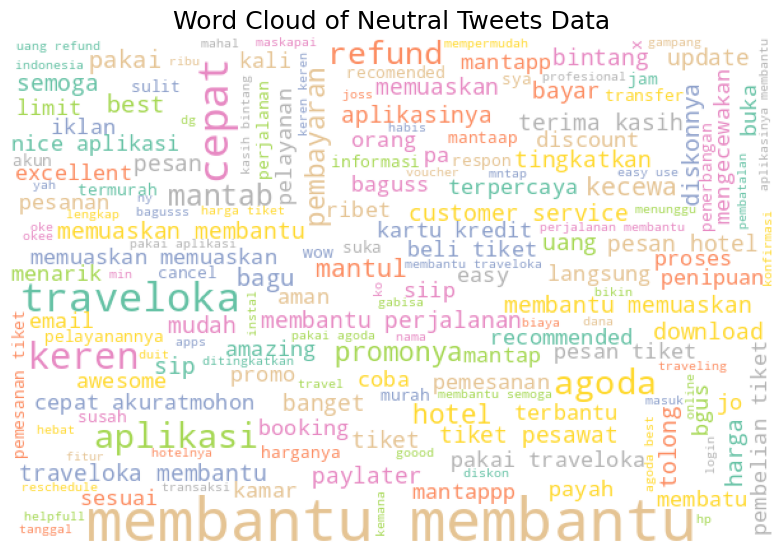

In [25]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet negatif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'neutral_tweets'.
for tweet in neutral_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', colormap='Set2',min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Neutral Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

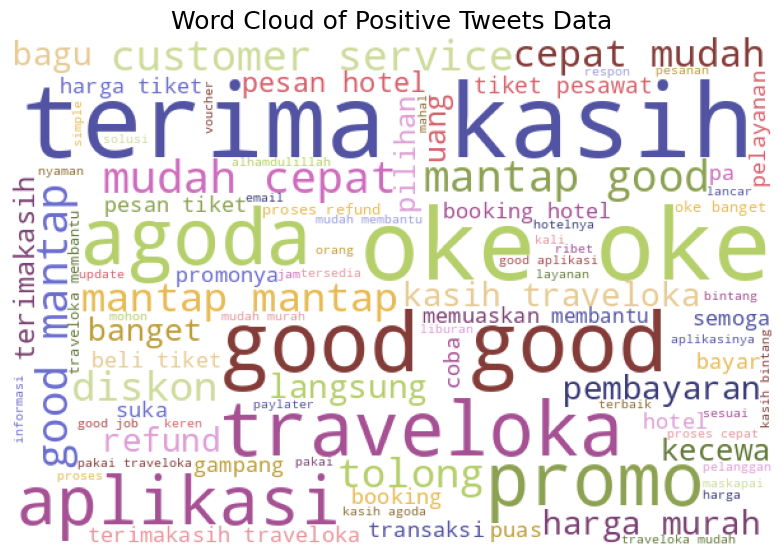

In [26]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet positif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'positive_tweets'.
for tweet in positive_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', colormap='tab20b',min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

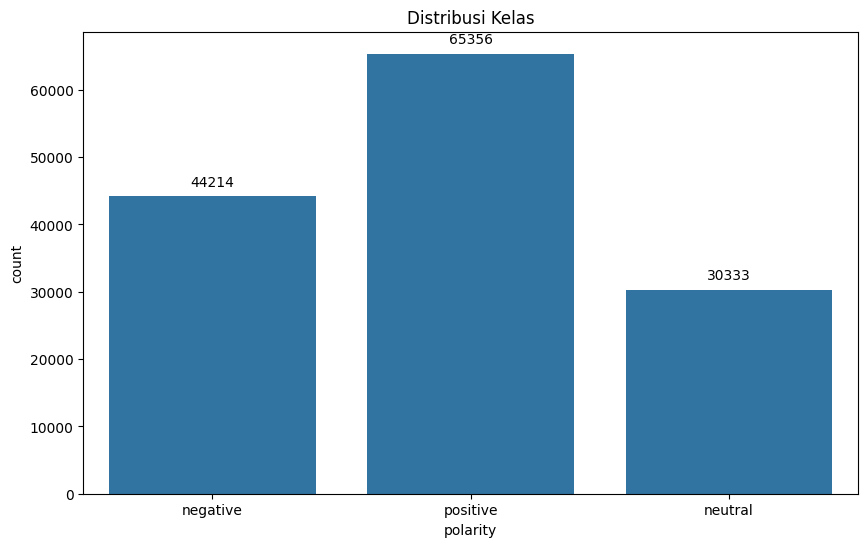

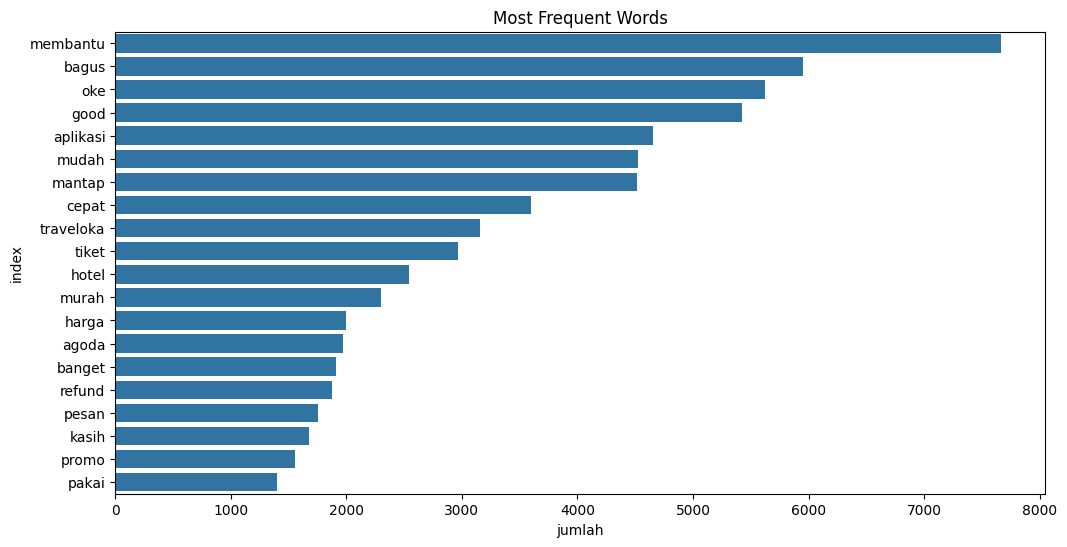

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Distribusi Kelas')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

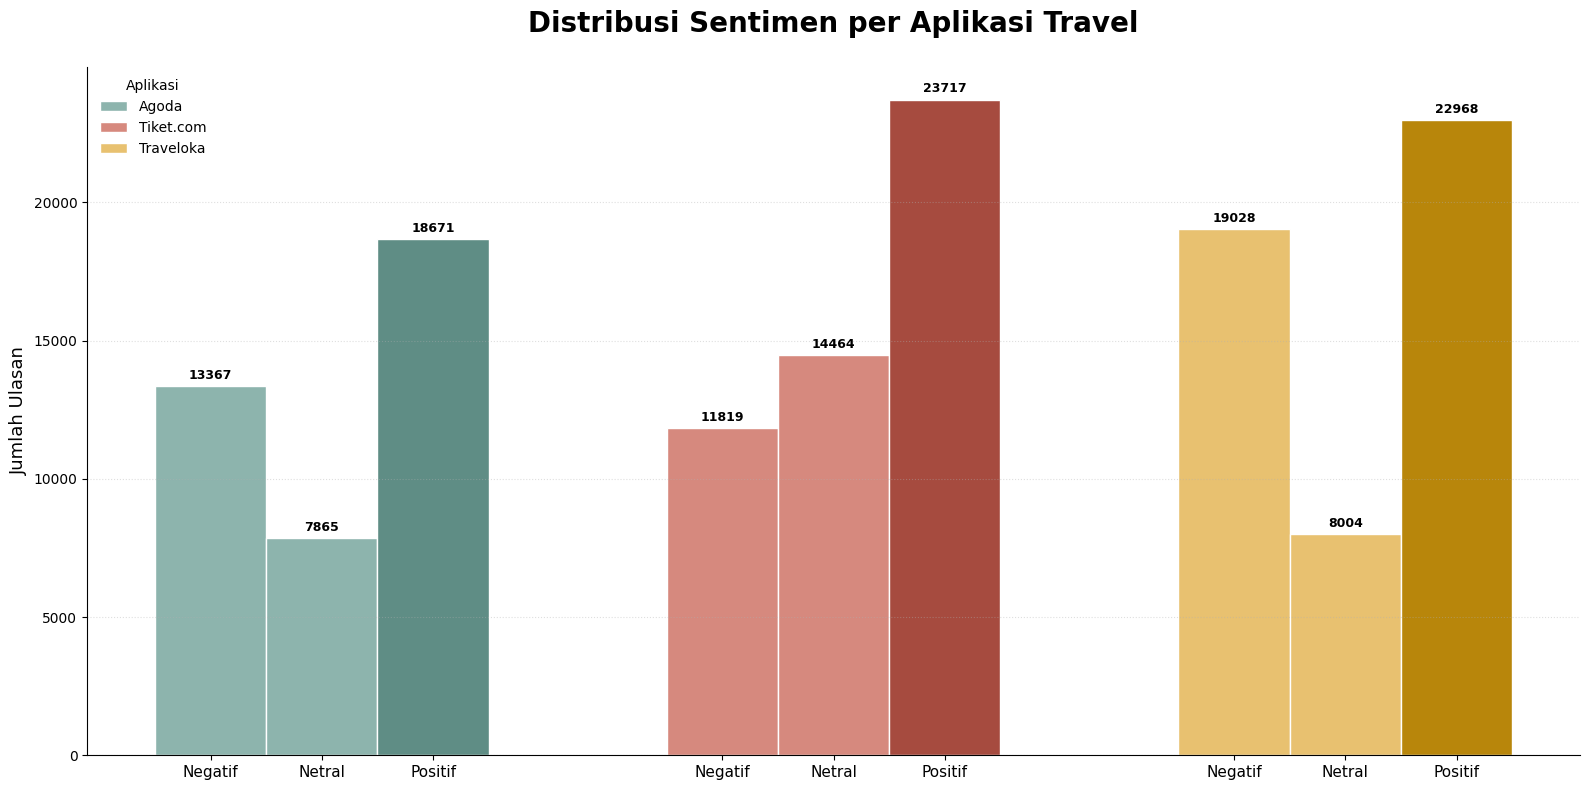

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
sentiment_counts = clean_df.groupby(['appName', 'polarity']).size().unstack(fill_value=0)

polarities = ['negative', 'neutral', 'positive']
sentiment_counts = sentiment_counts.reindex(columns=polarities).fillna(0)

apps = sentiment_counts.index
n_apps = len(apps)
n_pols = len(polarities)

# Mapping Warna per aplikasi
color_map = {
    apps[0]: {'bold': '#5F8D85', 'soft': '#8DB4AD'},
    apps[1]: {'bold': '#A64B3F', 'soft': '#D6897E'},
    apps[2]: {'bold': '#B8860B', 'soft': '#E8C170'}
}

fig, ax = plt.subplots(figsize=(16, 8))

width = 0.25
group_width = n_pols * width
gap = 0.4  # jarak antar grup

# Posisi awal tiap grup aplikasi
x = np.arange(n_apps) * (group_width + gap)

label_map = {
    'negative': 'Negatif',
    'neutral': 'Netral',
    'positive': 'Positif'
}

#  Plot per aplikasi 
for i, app in enumerate(apps):
    
    counts = sentiment_counts.loc[app]
    max_value = counts.max()
    
    # 3 bar dalam 1 grup 
    positions = x[i] + np.arange(n_pols) * width

    bar_colors = [
        color_map[app]['bold'] if counts[pol] == max_value 
        else color_map[app]['soft']
        for pol in polarities
    ]
    
    bars = ax.bar(
        positions,
        counts,
        width=width,
        color=bar_colors,
        label=app,
        edgecolor='white'
    )
    
    ax.bar_label(bars, padding=3, fontsize=9, fontweight='bold')

all_positions = []
all_labels = []

for i in range(n_apps):
    for j, pol in enumerate(polarities):
        all_positions.append(x[i] + j * width)
        all_labels.append(label_map[pol])

ax.set_xticks(all_positions)
ax.set_xticklabels(all_labels, fontsize=11)

# Styling
ax.set_title(
    'Distribusi Sentimen per Aplikasi Travel',
    fontsize=20,
    fontweight='bold',
    pad=25
)

ax.set_ylabel('Jumlah Ulasan', fontsize=13)
ax.legend(title="Aplikasi", frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

# **Data Splitting**

In [29]:
clean_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,appName,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity
0,a8745141-90b9-4560-b017-3a52c2932816,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Awlanya sih Tertarik ya pas udah ada TPayleter, setelahnya menggunakan beberap kali TPayleternya serasa kebantu. tapi akhir² ini mau bayar pakai TPAYLETER malah muncul Notif ""Limit anda tidak berkurang, Silahkan Pilih metode pembayaran lainnya"". trus fungsi ngasih limit buat apa kalau gak bisa di gunakan? padahal gak ada tunggakan alhasil balik Booking penginapan Pakai Aplikasi Agoda yang lebih murah dari pada disini harga lebih mahal. mau gunakan disini kalau TPayleter bisa digunakan lagi",1,0,5.39.0,2026-02-28 05:53:33,"Hai Hafidz, kami mohon maaf atas ketidaknyamanan yang Anda alami. Setelah kami cek, tampaknya masalah tersebut telah teratasi melalui email. Jika Anda masih memiliki pertanyaan lain, silakan hubungi kami melalui cs@paylater.co.id. Tim kami siap membantu Anda dan mencari solusi terbaik. -BM",2026-02-28 06:22:41,5.39.0,Traveloka,Awlanya sih Tertarik ya pas udah ada TPayleter setelahnya menggunakan beberap kali TPayleternya serasa kebantu tapi akhir² ini mau bayar pakai TPAYLETER malah muncul Notif Limit anda tidak berkurang Silahkan Pilih metode pembayaran lainnya trus fungsi ngasih limit buat apa kalau gak bisa di gunakan padahal gak ada tunggakan alhasil balik Booking penginapan Pakai Aplikasi Agoda yang lebih murah dari pada disini harga lebih mahal mau gunakan disini kalau TPayleter bisa digunakan lagi,awlanya sih tertarik ya pas udah ada tpayleter setelahnya menggunakan beberap kali tpayleternya serasa kebantu tapi akhir² ini mau bayar pakai tpayleter malah muncul notif limit anda tidak berkurang silahkan pilih metode pembayaran lainnya trus fungsi ngasih limit buat apa kalau gak bisa di gunakan padahal gak ada tunggakan alhasil balik booking penginapan pakai aplikasi agoda yang lebih murah dari pada disini harga lebih mahal mau gunakan disini kalau tpayleter bisa digunakan lagi,awlanya sih tertarik iya pas sudah ada tpayleter setelahnya menggunakan beberap kali tpayleternya serasa kebantu tapi akhir² ini mau bayar pakai tpayleter bahkan muncul notif limit anda tidak berkurang silahkan pilih metode pembayaran lainnya terus fungsi memberikan limit buat apa kalau gak bisa di gunakan padahal gak ada tunggakan alhasil balik booking penginapan pakai aplikasi agoda yang lebih murah dari pada disini harga lebih mahal mau gunakan disini kalau tpayleter bisa digunakan lagi,"[awlanya, sih, tertarik, iya, pas, sudah, ada, tpayleter, setelahnya, menggunakan, beberap, kali, tpayleternya, serasa, kebantu, tapi, akhir², ini, mau, bayar, pakai, tpayleter, bahkan, muncul, notif, limit, anda, tidak, berkurang, silahkan, pilih, metode, pembayaran, lainnya, terus, fungsi, memberikan, limit, buat, apa, kalau, gak, bisa, di, gunakan, padahal, gak, ada, tunggakan, alhasil, balik, booking, penginapan, pakai, aplikasi, agoda, yang, lebih, murah, dari, pada, disini, harga, lebih, mahal, mau, gunakan, disini, kalau, tpayleter, bisa, digunakan, lagi]","[awlanya, tertarik, pas, tpayleter, setelahnya, beberap, kali, tpayleternya, serasa, kebantu, akhir², bayar, pakai, tpayleter, muncul, notif, limit, berkurang, silahkan, pilih, metode, pembayaran, fungsi, limit, tunggakan, alhasil, booking, penginapan, pakai, aplikasi, agoda, murah, harga, mahal, tpayleter]",awlanya tertarik pas tpayleter setelahnya beberap kali tpayleternya serasa kebantu akhir² bayar pakai tpayleter muncul notif limit berkurang silahkan pilih metode pembayaran fungsi limit tunggakan alhasil booking penginapan pakai aplikasi agoda murah harga mahal tpayleter,-5,negative
1,717ea19a-d102-46f3-8b40-4d466aba7147,Pengguna Google,https://play-lh.googleusercontent

In [30]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

# Pemodelan

## IndoBERT

In [31]:
# Install library
!pip install transformers datasets accelerate -q
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [32]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from transformers import TrainingArguments, Trainer
from datasets import Dataset
import evaluate
import transformers
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold
from transformers import EarlyStoppingCallback
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score
import torch

In [33]:
# Encode Label
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_labels = len(label_encoder.classes_)
num_labels

3

In [34]:
# save mapping
label_mapping = dict(zip(label_encoder.classes_, range(num_labels)))
label_mapping

{'negative': 0, 'neutral': 1, 'positive': 2}

In [35]:
# Load indoBERT
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [36]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",    
        truncation=True,
        max_length=256
    )

In [37]:
training_args = TrainingArguments(
    output_dir="./results",          # folder simpan model dan log
    eval_strategy="epoch",           # evaluasi tiap epoch
    save_strategy="epoch",           # simpan model tiap epoch
    logging_strategy="epoch",        # log tiap epoch
    learning_rate=1e-5,              # learning rate default untuk BERT
    per_device_train_batch_size=16,  # batch size saat training
    per_device_eval_batch_size=16,   # batch size saat evaluasi
    num_train_epochs=3,              # jumlah epoch
    weight_decay=0.01,               # regularisasi
    load_best_model_at_end=True,     # load model terbaik otomatis
    metric_for_best_model="f1",      # metric yang dipakai untuk best model
    save_total_limit=2,              # simpan maksimal 2 model terbaik
    seed=42,                         # supaya reproducible
)

In [38]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.class_weights is not None:
            self.class_weights = self.class_weights.to(logits.device)

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights,label_smoothing=0.1)
        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [39]:
f1_metric = evaluate.load("f1")

# Membuat fungsi compute_metrics untuk Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred  # unpack
    predictions = np.argmax(logits, axis=-1)  # memilih kelas dengan score tertinggi
    acc = (predictions == labels).mean()      # menghitung akurasi
    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="macro"
    )["f1"]
    return {
        "accuracy": acc,
        "f1": f1
    }

In [40]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded)

In [41]:
X_train = pd.Series(X_train).reset_index(drop=True)
y_train = pd.Series(y_train).reset_index(drop=True)

X_test = pd.Series(X_test).reset_index(drop=True)
y_test = pd.Series(y_test).reset_index(drop=True)

In [42]:
# LOAD MODEL
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

# DATASET TRAIN
train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

train_dataset = train_dataset.map(tokenize_function, batched=True)
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# DATASET TEST
test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

test_dataset = test_dataset.map(tokenize_function, batched=True)
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Map:   0%|          | 0/118917 [00:00<?, ? examples/s]

Map:   0%|          | 0/20986 [00:00<?, ? examples/s]

In [43]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.452001,0.387923,0.950157,0.944791
2,0.371114,0.368713,0.960069,0.954830
3,0.344421,0.356862,0.968789,0.964529


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=11151, training_loss=0.3891788318802686, metrics={'train_runtime': 9604.0941, 'train_samples_per_second': 37.146, 'train_steps_per_second': 1.161, 'total_flos': 4.693298744394086e+16, 'train_loss': 0.3891788318802686, 'epoch': 3.0})

### Evaluasi

In [44]:
# TRAIN SET EVALUATION
train_predictions = trainer.predict(train_dataset)
y_train_pred = np.argmax(train_predictions.predictions, axis=1)

print("===== TRAIN SET =====")
print(classification_report(y_train, y_train_pred, target_names=label_encoder.classes_))
print("Confusion Matrix (Train):")
print(confusion_matrix(y_train, y_train_pred))

# TEST SET EVALUATION
test_predictions = trainer.predict(test_dataset)
y_test_pred = np.argmax(test_predictions.predictions, axis=1)

print("\n===== TEST SET =====")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


===== TRAIN SET =====
              precision    recall  f1-score   support

    negative       0.98      0.99      0.98     37582
     neutral       0.98      0.96      0.97     25783
    positive       0.99      0.99      0.99     55552

    accuracy                           0.98    118917
   macro avg       0.98      0.98      0.98    118917
weighted avg       0.98      0.98      0.98    118917

Confusion Matrix (Train):
[[37022   288   272]
 [  524 24807   452]
 [  218   213 55121]]


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



===== TEST SET =====
              precision    recall  f1-score   support

    negative       0.97      0.97      0.97      6632
     neutral       0.95      0.94      0.94      4550
    positive       0.98      0.98      0.98      9804

    accuracy                           0.97     20986
   macro avg       0.97      0.96      0.96     20986
weighted avg       0.97      0.97      0.97     20986

Confusion Matrix (Test):
[[6430  115   87]
 [ 138 4276  136]
 [  69  110 9625]]


## Logistik Regression

In [45]:
!pip install optuna

In [46]:
import optuna
from sklearn.model_selection import cross_val_score

In [47]:
# Bagi data menjadi data latih dan data uji
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(
    max_features=15000,
    min_df=5,             # min_df itu minimum kata(yg muncul di 5 dokumen),
    max_df=0.85,          # dan max dokumen yg memuat kata tersebut
    ngram_range=(1,3),
    sublinear_tf=True
)    
X_tfidf = tfidf.fit_transform(X_train_lr)
X_test_tfidf = tfidf.transform(X_test_lr)

In [49]:
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

,aa,aamiin,abaikan,abal,abal abal,abang,abisss,ac,acak,acara,...,yogya,yogyakarta,yok,youtube,yth,yu,yuk,yutub,zaman,zona
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
111918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
111919,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
111920,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Hyperparameter Tuning

In [50]:
def objective(trial):
    C = trial.suggest_float("C", 1e-3, 100, log=True) 
    
    # Menambahkan penalti L1/L2 untuk mengurangi overfitting
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    
    # Menggunakan solver liblinear karena mendukung l1 dan l2
    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver="liblinear", 
        max_iter=2000,
        class_weight=trial.suggest_categorical("class_weight", [None, "balanced"])
    )

    # StratifiedKFold 
    skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
    score = cross_val_score(model, X_tfidf, y_train_lr, cv=skf, scoring="f1_macro").mean()

    return score


In [51]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)

[I 2026-03-21 23:20:45,297] A new study created in memory with name: no-name-8a268b09-4247-4b95-87dc-4a36b46368f7
[I 2026-03-21 23:20:47,005] Trial 0 finished with value: 0.5768413154335561 and parameters: {'C': 0.006595067262749756, 'penalty': 'l1', 'class_weight': None}. Best is trial 0 with value: 0.5768413154335561.
[I 2026-03-21 23:20:49,207] Trial 1 finished with value: 0.8698868124233955 and parameters: {'C': 0.08043066076802283, 'penalty': 'l1', 'class_weight': None}. Best is trial 1 with value: 0.8698868124233955.
[I 2026-03-21 23:20:53,587] Trial 2 finished with value: 0.9066841082808897 and parameters: {'C': 0.6316250974984584, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.9066841082808897.
[I 2026-03-21 23:20:57,425] Trial 3 finished with value: 0.9498274871415214 and parameters: {'C': 2.789924714924856, 'penalty': 'l1', 'class_weight': None}. Best is trial 3 with value: 0.9498274871415214.
[I 2026-03-21 23:21:04,321] Trial 4 finished with valu

Best Params: {'C': 3.309486775541133, 'penalty': 'l1', 'class_weight': None}


### Evaluasi

In [52]:
best_lr = LogisticRegression(
    C=study.best_params["C"], penalty=study.best_params["penalty"], solver="liblinear", max_iter=2000, class_weight=study.best_params["class_weight"]
)

best_lr.fit(X_tfidf, y_train_lr)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = best_lr.predict(X_tfidf)
y_pred_test_lr = best_lr.predict(X_test_tfidf)

print("===== TRAIN SET =====")
print(classification_report(y_train_lr, y_pred_train_lr))

print("===== TEST SET =====")
print(classification_report(y_test_lr, y_pred_test_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test_lr, y_pred_test_lr))

===== TRAIN SET =====
              precision    recall  f1-score   support

    negative       0.96      0.99      0.98     35371
     neutral       0.98      0.92      0.95     24266
    positive       0.98      0.99      0.99     52285

    accuracy                           0.98    111922
   macro avg       0.98      0.97      0.97    111922
weighted avg       0.98      0.98      0.98    111922

===== TEST SET =====
              precision    recall  f1-score   support

    negative       0.95      0.97      0.96      8843
     neutral       0.96      0.90      0.93      6067
    positive       0.97      0.98      0.98     13071

    accuracy                           0.96     27981
   macro avg       0.96      0.95      0.95     27981
weighted avg       0.96      0.96      0.96     27981

Confusion Matrix:
[[ 8584   119   140]
 [  353  5444   270]
 [  114   108 12849]]


## **Multi Layer Perceptron(MLP)**

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [54]:
# Bagi data menjadi data latih dan data uji
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X, y, test_size=0.25, random_state=42,stratify=y)

In [55]:
# Ekstraksi fitur dengan TF-IDF
tfidf_nn = TfidfVectorizer(max_features=12000, min_df=2, max_df=0.8,ngram_range=(1,3) )   #min_df itu minimum kata(yg muncul di 17 dokumen), dan max dokumen yg memuat kata tersebut
X_tfidf_nn = tfidf_nn.fit_transform(X_train_nn)
X_test_tfidf_nn = tfidf_nn.transform(X_test_nn)

In [56]:
# ubah label menjadi angka
y_train_encoded = label_encoder.transform(y_train_nn)
y_test_encoded = label_encoder.transform(y_test_nn)

In [57]:
# Jalankan di GPU
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert data terlebih dahulu
X_train_tensor = torch.tensor(X_tfidf_nn.toarray(), dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long).to(device)

In [58]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SimpleMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    def forward(self, x):
        return self.layers(x)

input_dim = X_train_tensor.shape[1]
output_dim = len(torch.unique(y_train_tensor))

train_data = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_data, batch_size=200, shuffle=True)

model = SimpleMLP(input_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

### Training

In [59]:
model.train()
for epoch in range(30):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/50], Loss: {total_loss/len(train_loader):.4f}")

Epoch [5/50], Loss: 0.0706
Epoch [10/50], Loss: 0.0448
Epoch [15/50], Loss: 0.0367
Epoch [20/50], Loss: 0.0317
Epoch [25/50], Loss: 0.0281
Epoch [30/50], Loss: 0.0254


### Evaluasi

In [60]:
# Convert dahulu
X_test_tensor = torch.tensor(X_test_tfidf_nn.toarray(), dtype=torch.float32).to(device)

# Ambil prediksi train
model.eval() 
with torch.no_grad():
    outputs_train = model(X_train_tensor)
    _, y_pred_train_nn = torch.max(outputs_train, 1)
    y_pred_train_nn = y_pred_train_nn.cpu().numpy()

# Ambil prediksi test
with torch.no_grad():
    outputs_test = model(X_test_tensor)
    _, y_pred_test_nn = torch.max(outputs_test, 1)
    y_pred_test_nn = y_pred_test_nn.cpu().numpy()

In [61]:
# Convert dahulu
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long).to(device)

print("===== TRAIN SET =====")
print(classification_report(y_train_encoded, y_pred_train_nn))

print("===== TEST SET =====")
print(classification_report(y_test_encoded, y_pred_test_nn))

print(confusion_matrix(y_test_encoded, y_pred_test_nn))

===== TRAIN SET =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33160
           1       0.99      1.00      0.99     22750
           2       1.00      1.00      1.00     49017

    accuracy                           1.00    104927
   macro avg       1.00      1.00      1.00    104927
weighted avg       1.00      1.00      1.00    104927

===== TEST SET =====
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     11054
           1       0.92      0.90      0.91      7583
           2       0.96      0.97      0.96     16339

    accuracy                           0.95     34976
   macro avg       0.94      0.94      0.94     34976
weighted avg       0.95      0.95      0.95     34976

[[10494   301   259]
 [  410  6803   370]
 [  227   294 15818]]


# **Inference(Pengujian)**

Dalam penelitian analisis sentimen ini, model IndoBERT memperoleh akurasi pengujian tertinggi sebesar 97%. Meskipun demikian, kedua algoritma lainnya juga menunjukkan kemampuan generalisasi yang baik. Sehingga, saya memilih algoritma MLP untuk memprediksi sentimen pada kalimat-kalimat baru..

In [62]:
# Input kalimat baru dari pengguna
kalimat_baru = input("Masukkan kalimat baru: ")

# Melakukan preprocessing pada kalimat baru
kalimat_baru_cleaned = cleaningText(kalimat_baru)
kalimat_baru_casefolded = casefoldingText(kalimat_baru_cleaned)
kalimat_baru_slangfixed = fix_slangwords(kalimat_baru_casefolded)
kalimat_baru_tokenized = tokenizingText(kalimat_baru_slangfixed)
kalimat_baru_filtered = filteringText(kalimat_baru_tokenized)
kalimat_baru_final = toSentence(kalimat_baru_filtered)

# Menggunakan objek tfidf yang sudah di-fit dari pelatihan sebelumnya
X_kalimat_baru = tfidf.transform([kalimat_baru_final])

# Memperoleh prediksi sentimen kalimat baru
prediksi_sentimen = best_lr.predict(X_kalimat_baru)

# Menampilkan hasil prediksi
if prediksi_sentimen[0] == 'positive':
    print("Sentimen: POSITIF")
elif prediksi_sentimen[0] == 'neutral':
    print("Sentimen: NETRAL")
else:
    print("Sentimen: NEGATIF")

Masukkan kalimat baru:  Gaada sih, cuma mau blg baru download traveloka aja


Sentimen: NETRAL


In [64]:
!pip freeze > requirements.txt